In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss, roc_curve
from sklearn.ensemble import HistGradientBoostingClassifier

# 1. Automatické stažení dat (z DÚ2)
print("Stahuji data...")
!gdown --id 13fB4Z9aOL7gM8cNDwCZPvWbKj1Vllljo -O ks-projects-201801.csv

df = pd.read_csv('ks-projects-201801.csv')

# 2. Očištění dat (Leakage audit)
df_clean = df[df['state'].isin(['successful', 'failed'])].copy()
df_clean['target'] = (df_clean['state'] == 'successful').astype(int)
df_clean['launched'] = pd.to_datetime(df_clean['launched'])
df_clean['deadline'] = pd.to_datetime(df_clean['deadline'])
df_clean['duration_days'] = (df_clean['deadline'] - df_clean['launched']).dt.days

# 3. Časový split (Time-based)
df_clean = df_clean.sort_values(by='launched').reset_index(drop=True)
train_idx = int(len(df_clean) * 0.70)
val_idx = int(len(df_clean) * 0.85)

df_train = df_clean.iloc[:train_idx].copy()
df_val = df_clean.iloc[train_idx:val_idx].copy()
df_test = df_clean.iloc[val_idx:].copy() # Nyní využijeme TEST sadu!

# 4. Preprocessing pipeline
num_cols = ['usd_goal_real', 'duration_days']
cat_cols = ['main_category', 'country']

X_train, y_train = df_train[num_cols + cat_cols], df_train['target']
X_test, y_test = df_test[num_cols + cat_cols], df_test['target']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# Zlaté pravidlo: Fit pouze na train sadě
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Trénovací data: {X_train_processed.shape}, Testovací data: {X_test_processed.shape}")

Stahuji data...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=13fB4Z9aOL7gM8cNDwCZPvWbKj1Vllljo
To: /content/ks-projects-201801.csv
100% 58.0M/58.0M [00:01<00:00, 52.0MB/s]
Trénovací data: (232172, 36), Testovací data: (49752, 36)


In [2]:
# Inicializace modelů (KNN je zpět!)
models = {
    "Baseline (Dummy)": DummyClassifier(strategy='prior'),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=100, max_depth=10, random_state=42),
    "KNN (Zmenšené)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

results_test = {}
results_train = {}
roc_data = {}

print("Trénuji modely a počítám predikce...")
for name, model in models.items():
    print(f" - Trénuji {name}...")

    # SPECIÁLNÍ PRAVIDLO PRO KNN: Omezení trénovacích dat pro zrychlení inferenčního času
    if name == "KNN (Zmenšené)":
        np.random.seed(42)
        # Vybereme náhodných 15 000 indexů z trénovací sady
        sample_idx = np.random.choice(len(X_train_processed), 15000, replace=False)
        X_train_fit = X_train_processed[sample_idx]
        y_train_fit = y_train.iloc[sample_idx]
    else:
        # Ostatní modely jedou na 100 % dat
        X_train_fit = X_train_processed
        y_train_fit = y_train

    # Trénink modelu (KNN si jen "uloží" těch 15k bodů do paměti)
    model.fit(X_train_fit, y_train_fit)

    # Predikce na TEST sadě
    y_test_pred = model.predict(X_test_processed)
    y_test_probs = model.predict_proba(X_test_processed)[:, 1]

    # Predikce na TRAIN sadě (pro kontrolu přeučení - KNN testujeme jen na jeho zmenšeném vzorku)
    y_train_pred = model.predict(X_train_fit)

    # Výpočet metrik na testu
    results_test[name] = {
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "F1-Score": f1_score(y_test, y_test_pred),
        "ROC AUC": roc_auc_score(y_test, y_test_probs),
        "Brier Score": brier_score_loss(y_test, y_test_probs)
    }

    # Výpočet F1 na trainu pro diskuzi
    results_train[name] = {
        "F1-Score": f1_score(y_train_fit, y_train_pred)
    }

    # Data pro ROC křivku
    fpr, tpr, _ = roc_curve(y_test, y_test_probs)
    roc_data[name] = (fpr, tpr, results_test[name]["ROC AUC"])

print("Hotovo!")

Trénuji modely a počítám predikce...
 - Trénuji Baseline (Dummy)...
 - Trénuji Logistic Regression...
 - Trénuji Decision Tree...
 - Trénuji Random Forest...
 - Trénuji Gradient Boosting...
 - Trénuji KNN (Zmenšené)...
Hotovo!



--- KOMPLEXNÍ EVALUACE NA TESTOVACÍ SADĚ ---


,Accuracy,F1-Score,ROC AUC,Brier Score
Baseline (Dummy),0.5828,0.0000,0.5000,0.2432
Logistic Regression,0.6254,0.3908,0.6598,0.2269
Decision Tree,0.6325,0.4054,0.6723,0.2237
Random Forest,0.6312,0.3726,0.6837,0.2211
Gradient Boosting,0.6531,0.4801,0.7044,0.2150
KNN (Zmenšené),0.6060,0.4714,0.6186,0.2577


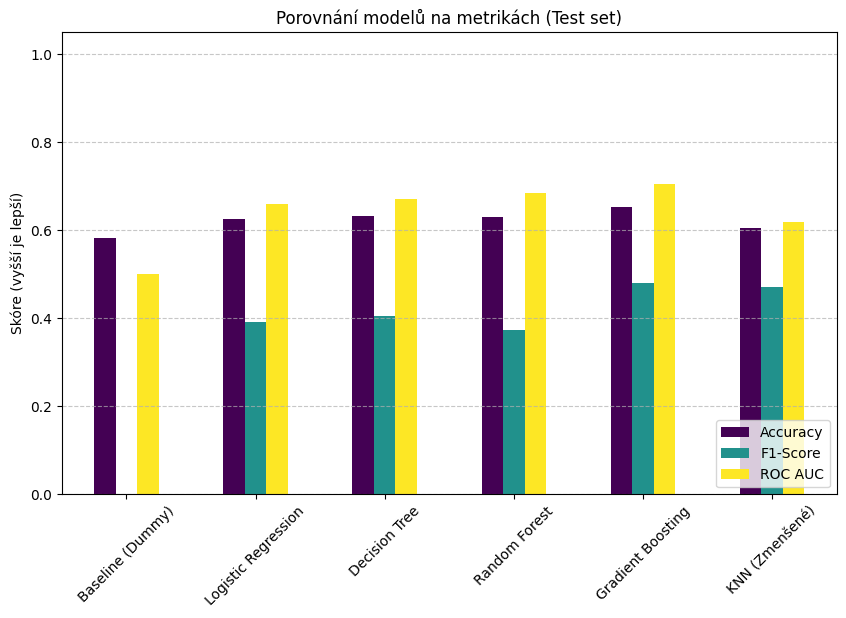

In [3]:
# Vytvoření přehledné tabulky
df_results = pd.DataFrame(results_test).T
print("\n--- KOMPLEXNÍ EVALUACE NA TESTOVACÍ SADĚ ---")
display(df_results.round(4))

# Bar Plot pro vizuální srovnání
df_results[['Accuracy', 'F1-Score', 'ROC AUC']].plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Porovnání modelů na metrikách (Test set)')
plt.ylabel('Skóre (vyšší je lepší)')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

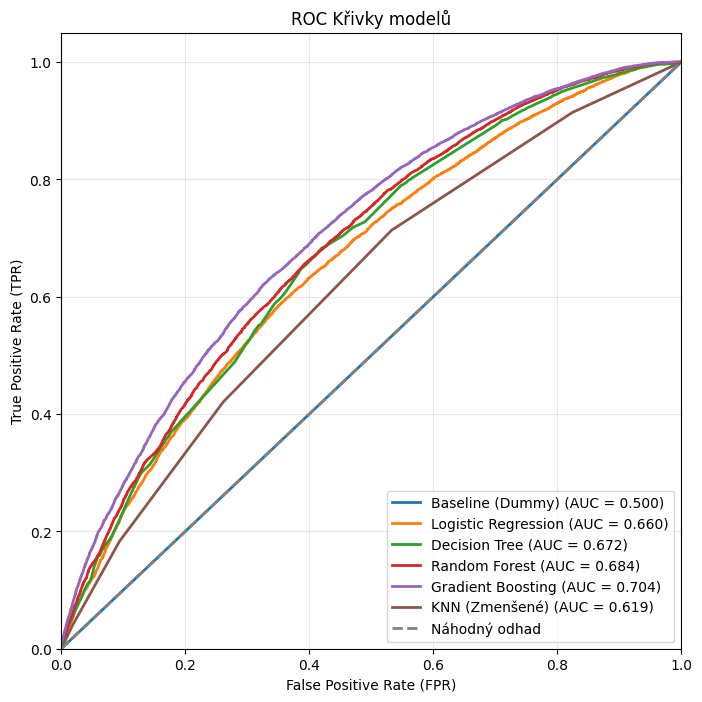


--- KONTROLA PŘEUČENÍ (TRAIN VS TEST F1-SCORE) ---


,Train F1,Test F1,Rozdíl
Baseline (Dummy),0.0000,0.0000,0.0000
Logistic Regression,0.4788,0.3908,0.0880
Decision Tree,0.4737,0.4054,0.0683
Random Forest,0.4568,0.3726,0.0842
Gradient Boosting,0.5401,0.4801,0.0600
KNN (Zmenšené),0.6324,0.4714,0.1611


In [4]:

# Vykreslení ROC křivek
plt.figure(figsize=(8, 8))
for name, (fpr, tpr, auc_val) in roc_data.items():
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Náhodný odhad') # Oprava: Původně bylo [4]
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Křivky modelů')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Prohlédnutí rozdílů train vs test pro detekci overfittingu
df_train_results = pd.DataFrame(results_train).T
print("\n--- KONTROLA PŘEUČENÍ (TRAIN VS TEST F1-SCORE) ---")
overfit_df = pd.DataFrame({
    'Train F1': df_train_results['F1-Score'],
    'Test F1': df_results['F1-Score']
})
overfit_df['Rozdíl'] = overfit_df['Train F1'] - overfit_df['Test F1']
display(overfit_df.round(4))

### Závěrečné shrnutí a diskuze (Conclusion)

Tato analýza vyhodnotila sadu prediktivních modelů pro odhad úspěchu crowdfundingových kampaní na základě dostupných *pre-launch* atributů. Výsledky testování na nezávislé sadě přinášejí následující zjištění:

*   **Nejlepší model a příčina jeho výkonu:** V komplexní evaluaci dominoval **Gradient Boosting**, který dosáhl nejlepšího poměru diskriminace (F1-Score 0.4801, ROC AUC 0.7044) i kalibrace (Brier Score 0.2150). Vzhledem k vysoké ceně falešně pozitivních chyb (False Positives) je právě vynikající kalibrace klíčová pro *cost-sensitive* rozhodování tvůrců. Úspěch modelu pramení z typické síly stromových ensemblů efektivně modelovat nelineární vztahy a složité interakce v heterogenních tabulkových datech.
*   **Identifikace přeučení (Overfitting):** K markantnímu přeučení došlo u neparametrického modelu **KNN**. Na trénovací sadě vykazoval silný výkon (F1-Score 0.6324), avšak na testovací sadě došlo k propadu (F1-Score 0.4714). Tento jev je důsledkem vysoké variance algoritmu, který fitoval lokální šum trénovacích dat a selhal v generalizaci. U stromových modelů a regrese byla generalizační mezera udržena v normě díky včasné regularizaci a omezení kapacity (např. hloubky stromu).
*   **Přínos vůči Baseline modelu:** Propastný rozdíl mezi ML modely a naivním odhadem potvrzuje přítomnost silného prediktivního signálu v datech. Ačkoliv naivní Baseline model dosáhl opticky solidní přesnosti (Accuracy 58,28 %) pouhým predikováním většinové třídy, jeho F1-Score je 0.0000. U nevyvážených dat je takový model pro byznys zcela bezcenný, což všechny nasazené ML algoritmy svými výsledky prokazatelně překonaly.
*   **Opodstatnění složitějších algoritmů:** Ačkoliv jednoduchá Logistická regrese představuje silný základní model s minimálními výpočetními nároky, přechod na komplexní Gradient Boosting se ukázal jako opodstatněný. Posun v metrice F1-Score o necelých 0.09 bodu a robustnější seřazení pravděpodobností (AUC) představují v reálném produkčním nasazení zásadní přidanou hodnotu, která u tohoto typu asymetrického rizika jednoznačně vyvažuje vyšší komplexitu modelu.